# **PyTorch Tutorial: Building Neural Networks**

> Quick Prelude:

*Why PyTorch over TensorFlow?*

* PyTorch is easier for beginners.
* PyTorch has significant traction in the research community.
* TensorFlow generally better for industrial uses (massive production and deployment).
* Other computational differences that are not as important.

*Why Neural Networks?*

* Still trying to figure this one out but it is important for my DSS Decal project; I guess we'll find out later.


> Tensors

Tensors: Specialized data structure similar to arrays/matrices.
* Used to encode inputs/outputs + parameters of a model.
* Tensors can run on GPUs/other hardware accelerators.
* Tensors are optimized for automatic differentiation.

> Initializing Tensors:

In [ ]:
import torch
import numpy as np

In [ ]:
# Directly from Python lists
data = [[1,2],[3,4]]
x_data = torch.tensor(data)

In [ ]:
# Directly from NumPy Arrays
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

In [ ]:
# From another tensor
x_ones = torch.ones_like(x_data) # retains properties of x_data
print(f"Ones Tensor \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides datatype
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.6185, 0.3581],
        [0.0899, 0.0332]]) 



In [ ]:
# Prebuilt tensors
shape = (2,3) # shape: a tuple of tensor dimensions
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor} \n")


Random Tensor: 
 tensor([[0.1203, 0.7070, 0.6636],
        [0.6700, 0.3485, 0.6562]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]]) 



In [ ]:
# Tensor attributes
tensor = torch.rand(3,4)

print(f"Shape: {tensor.shape}")
print(f"Datatype: {tensor.dtype}")
print(f"Device Stored On: {tensor.device}")

Shape: torch.Size([3, 4])
Datatype: torch.float32
Device Stored On: cpu


> Tensor Operations

First, tensors are stored by default on the CPU. Explicitly move tensors to the GPU to perform large operations.

Note: Copying large tensors across devices is expensive in time and memory.

Most Torch operations are analogous to NumPy.

In [ ]:
# Moving tensor to GPU
if torch.accelerator.is_available():
  tensor = tensor.to(torch.accelerator.current_accelerator())

In [ ]:
print(f"Device Stored On: {tensor.device}") # success!

Device Stored On: cuda:0


In [ ]:
# Indexing and Slicing
tensor = torch.ones(4,4) # Use CPU for these tasks to prevent GPU overuse for now
print(f"First row: {tensor[0]}")
print(f"First column {tensor[:,0]}")
print(f"Last column: {tensor[..., -1]}") # ... also works like :, I guess
tensor[:,1] = 0
print(tensor)

First row: tensor([1., 1., 1., 1.])
First column tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])
tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [ ]:
# Concatenation
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


In [ ]:
# Matrix Multiplication
  # ``tensor.T`` is the transpose of a tensor
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T) # same thing

y3 = torch.rand_like(y1)
torch.matmul(tensor, tensor.T, out=y3) # same thing

tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])

In [ ]:
# Element-Wise Product

z1 = tensor * tensor
z2 = tensor.mul(tensor) # same thing

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out=z3) # same thing

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

In [ ]:
# Aggregation

agg = tensor.sum() # a single-element tensor
print(agg, type(agg))

agg_item = agg.item() # a float
print(agg_item, type(agg_item))

tensor(12.) <class 'torch.Tensor'>
12.0 <class 'float'>


In [ ]:
# In-Place Operations
  # In-place operations store the result into the original operand
    # They are denoted with the _ suffix

print(tensor, "\n")
tensor.add_(5)
print(tensor)

# In-place operators save memory but are discouraged because of an immediate loss of history when computing derivatives

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])


> Bridging with NumPy

PyTorch and Numpy works together in a way such that tensors in the CPU can share memory locations with a corresponding NumPy array.

In [ ]:
# Tensor to NumPy
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


In [ ]:
# Both the tensor and the NumPy array are changed
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


In [ ]:
# NumPy to Tensor
n = np.ones(5)
t = torch.from_numpy(n)

In [ ]:
np.add(n, 1, out=n) # In-place operation in NumPy
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


> Dealing with Data

PyTorch offers two data primitives: Dataset and DataLoader.

* Dataset stores samples and corresponding labels.

* DataLoader is an iterable that wraps around Dataset for easy access to elements

PyTorch offers a set of preloaded datasets under Dataset with their own functions specific to the dataset. They can be used to prototype/benchmark personal models.

Today we will be working with the famed Fashion-MNIST dataset from TorchVision.

> "Fashion-MNIST is a dataset of Zalando's article images consisting of 60,000 training examples and 10,000 test examples. Each example comprises a 28x28 grayscale image and an associated label from one of 10 classes." - PyTorch Documentation

In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data", # path where train/test data is stored
    train=True, # specifies training dataset
    download=True, # downloads from internet if not in root
    transform=ToTensor() # transform and target_transform specifies feature/label transformations
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False, # specifies testing dataset
    download=True,
    transform=ToTensor()
)

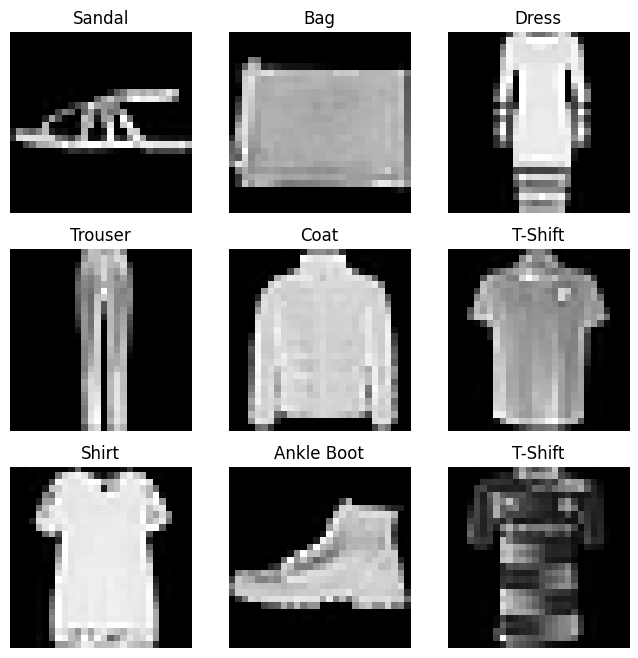

In [ ]:
# Visualizing samples
labels_map = {
    0: "T-Shift",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8,8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
  sample_idx = torch.randint(len(training_data), size=(1,)).item() # Random Sampling
  img, label = training_data[sample_idx] # Pulling the data
  figure.add_subplot(rows, cols, i)
  plt.title(labels_map[label]) # Name title by label
  plt.axis("off")
  plt.imshow(img.squeeze(), cmap="gray")
plt.show()

> Custom Datasets

We are creating a custom Dataset class for FashionMNIST for some reason. My guess is that it makes training much easier.

A custom Dataset class must implement three functions: *\_\__init___*, *\_\__len___*, and *\_\__getitem___*.

FashionMNIST images are stored in the directory *img_dir*, and their labels in a CSV file *annotations_file.csv*.

Note: The labels file looks something like this:

```
tshirt1.jpg, 0
tshirt2.jpg, 0
......
ankleboot999.jpg, 9
```

where each row has a filename at .iloc[idx,0] and a corresponding labels at .iloc[idx,1].


In [ ]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
  def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
    self.img_labels = pd.read_csv(annotations_file) # Initialize labels
    self.img_dir = img_dir # Initialize images
    self.transform = transform # Initialize both transforms (see below)
    self.target_transform = target_transform

  def __len__(self):
    return len(self.img_labels) # Returns # of samples in dataset

  def __getitem__(self, idx):
    img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx,0]) # Gets image location
    image = decode_image(img_path) # converts image to tensor
    label = self.img_labels.iloc[idx,1] # finds label from document
    if self.transform: # transforms if applicable
      image = self.transform(image)
    if self.target_transform:
      label = self.target_transform(label)
    return image, label # returns image and label

> DataLoaders

Remember that DataLoaders are an iterable form of a Dataset. For highly technical reasons (including model overfitting), we will be randomly sampling "minibatches" to input into our model at a time.

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


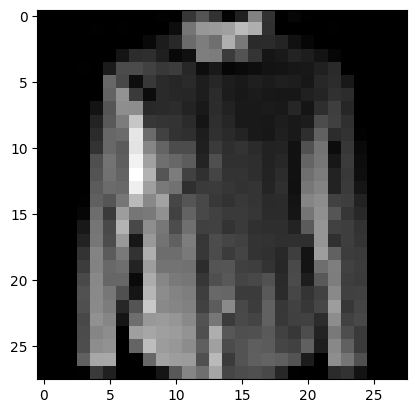

Label: 6


In [ ]:
# Displaying Image and Label with DataLoader
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

> Transforms

Data must be fully processed into a numerical final form readable by algorithms to train machine learning models. Transforms are used to perform manipulation on the data.

The TorchVision parameters *transform* and *target_transform* helps modify features and labels through their inputted functions.

In FashionMNIST, images are in PIL Image format and labels are integers. The image features should be converted into normalized tensors, and the labels into one-hot encoded tensors.

*ToTensor()* converts PIL images or NumPy ndarrays into a *FloatTensor* and scales image pixel intensity values between [0,1].

*Lambda()* applies any user-defined lambda function. The function below creates a one-hot encoded tensor by creating a zero tensor of size 10 and assigning the value 1 to the index given by label y.

In [ ]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

> Neural Networks

A neural network is a module that consists of other modules (or layers). The layers come together to build a complex architecture that performs operations on data. Ultimately, these operations will come together to form our final machine learning model.

In [ ]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [ ]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10),
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits

In [ ]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:
# Using the model
X = torch.rand(1, 28, 28, device=device)
logits = model(X) # this executes forward() implicitly. Do not directly call forward()!

print(logits) # This now contains a tensor containing the prediction values

pred_probab = nn.Softmax(dim=1)(logits) # This converts values to probabilities
y_pred = pred_probab.argmax(1) # This grabs the index of the largest probability
print(f"Predicted class: {y_pred}")

tensor([[-0.0157, -0.0317,  0.0786,  0.1138,  0.0673, -0.0573,  0.0835, -0.0493,
         -0.0156, -0.0143]], device='cuda:0', grad_fn=<AddmmBackward0>)
Predicted class: tensor([3], device='cuda:0')


> Exploring the Model

To explore the underlayers of this FashionMNIST model, we will take a sample of 3 images of size 28x28 and track its progression through the model.

In [ ]:
input_image = torch.rand(3,28,28) # This is technically a RNG but it works for the demo
print(input_image.size())

torch.Size([3, 28, 28])


In [ ]:
# nn.Flatten converts the 2D 28x28 images into a single array of 784 pixels
flatten = nn.Flatten()
flat_image = flatten(input_image)
print(flat_image.size())

torch.Size([3, 784])


In [ ]:
# nn.Linear applies a linear transformation on the input with its stored weights and biases
layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print(hidden1.size())

torch.Size([3, 20])


In [ ]:
# nn.ReLU is a type of non-linear activation.
# It creates the complex mappings between the model's input and outputs.
# They are applied after linear transformations to introduce *nonlinearity*
# Nonlinearity helps neural networks learn widely, not just specifically

print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

Before ReLU: tensor([[-0.1859,  0.5684,  0.0460, -0.1407,  0.3236,  0.2866, -0.1432, -0.0311,
          0.3245, -0.0193, -0.9863, -0.0996, -0.0843,  0.1903,  0.2867, -0.2720,
          0.0366,  0.0742, -0.7286, -0.4701],
        [ 0.0247,  0.6694,  0.0325, -0.1322, -0.0048,  0.3953, -0.3057, -0.2811,
          0.0341, -0.1016, -0.8041, -0.1739, -0.1788,  0.0799,  0.1806, -0.2680,
         -0.0772, -0.1404, -0.1545, -0.2785],
        [ 0.0670,  0.2407,  0.2189, -0.1430,  0.3113,  0.2892, -0.1272, -0.5164,
         -0.0433, -0.1578, -0.7323, -0.0307, -0.4429,  0.1930,  0.4327, -0.4355,
         -0.0988,  0.0661, -0.4031,  0.1175]], grad_fn=<AddmmBackward0>)


After ReLU: tensor([[0.0000, 0.5684, 0.0460, 0.0000, 0.3236, 0.2866, 0.0000, 0.0000, 0.3245,
         0.0000, 0.0000, 0.0000, 0.0000, 0.1903, 0.2867, 0.0000, 0.0366, 0.0742,
         0.0000, 0.0000],
        [0.0247, 0.6694, 0.0325, 0.0000, 0.0000, 0.3953, 0.0000, 0.0000, 0.0341,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0799, 0.18

In [ ]:
# nn.Sequential essentially directs the order of processes to be run
seq_modules = nn.Sequential(
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20,10)
)
input_image = torch.rand(3,28,28)
logits = seq_modules(input_image)

In [ ]:
# logits are raw values between (-inf, inf)
# nn.Softmax takes the logits and scales them down between [0,1]
# These values represent the probability of each class
# The dim parameter indicates which dimension needs to sum to 1
softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)

In [ ]:
# Many neural network layers are paramterized (have stored weights and biases optimized during training)
# by subclassing nn.Module we can automatically track parameters with parameters() or named_parameters()

print(f"Module structure: {model}\n\n")

for name, param in model.named_parameters():
  print(f"Layer: {name} | Size: {param.size()} | Values: {param[:2]} \n")

Module structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values: tensor([[ 0.0350,  0.0035, -0.0169,  ..., -0.0174,  0.0218, -0.0195],
        [ 0.0205, -0.0354, -0.0105,  ..., -0.0248,  0.0269,  0.0155]],
       device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values: tensor([-0.0100,  0.0163], device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values: tensor([[-0.0105,  0.0228, -0.0279,  ...,  0.0243,  0.0076, -0.0265],
        [ 0.0322, -0.0308, -0.0394,  ..., -0.0395,  0.0180,  0.0059]],
       device='cuda:0', grad_fn=<Slic

> Training Neural Networks

The most common algorithm for neural network training is called **back propagation**, where parameters are adjusted by the gradient of the loss function w.r.t. to given parameters.

The differentiation engine *torch.autograd* automatically computes gradients of computational graphs.

In [ ]:
# Simplest example of a neural network
import torch

x = torch.ones(5)
y = torch.zeros(3)
w = torch.randn(5,3,requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w)+b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z,y) # a loss function measures the accuracy of a model's prediction
# binary cross entropy is a common loss function for classification models

The above code builds the following computational graph:

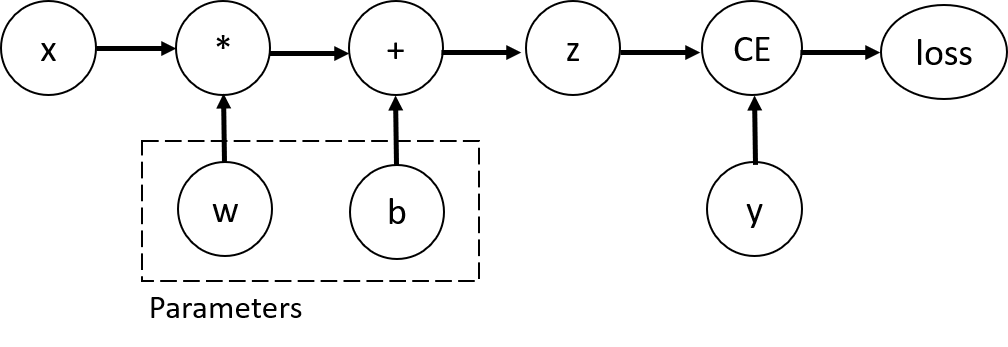

*w* and *b* are the parameters to optimize, so we will set their *requires_grad* parameters to True.

The functions we apply to the parameters contain both instructions to compute the forward pass as well as its derivative for backward propagation, stored in the function's *grad_fn* property.

In [ ]:
print(f"Gradient function for z = {z.grad_fn}")
print(f"Gradient function for loss = {loss.grad_fn}")

Gradient function for z = <AddBackward0 object at 0x7f42ab3dc730>
Gradient function for loss = <BinaryCrossEntropyWithLogitsBackward0 object at 0x7f42ab366d40>


In [ ]:
# finding the derivatives of our parameters
loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.2332, 0.0295, 0.2773],
        [0.2332, 0.0295, 0.2773],
        [0.2332, 0.0295, 0.2773],
        [0.2332, 0.0295, 0.2773],
        [0.2332, 0.0295, 0.2773]])
tensor([0.2332, 0.0295, 0.2773])


In [ ]:
# all tensors that require gradients track computational history forever
# if we only need forward computations, we can disable computation tracking for that runthrough

z = torch.matmul(x,w)+b
print(z.requires_grad)

with torch.no_grad():
  z = torch.matmul(x,w)+b
print(z.requires_grad)

# or

z = torch.matmul(x,w)+b
z_det = z.detach()
print(z_det.requires_grad)

True
False
False


> Optimizing Model Parameters

Training a model is an iterative process; in each iteration, the model guesses the output, calculates its loss, finds the derivative of the errors w.r.t. parameters, and optimizes them through gradients descent.

The following examples rely on our previous code examining FashionMNIST.

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

In [ ]:
# Hyperparameters impact model training and convergence rates.

learning_rate = 1e-3 # how much to update parameters at each batch/epoch
batch_size = 64 # number of data samples evaluated before parameters update
epochs = 5 # number of iterations

The Optimization Loop is the full process of optimizing our model.

Each iteration of the loop is called an *epoch*. An epoch has two main parts: the Train loop (where parameters are adjusted) and the Test loop (where performance is tested)

In [ ]:
# Loss Function: Accuracy of a model's prediction
loss_fn = nn.CrossEntropyLoss() # a type of classification loss

In [ ]:
# Optimizer: Algorithm defining how to parameters are adjusted to reduce model error
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) # Stochastic Gradient Descent optimizer

Exploring the Training Loop:
* Call *optimizer.zero_grad()* to reset gradient model parameters (bc gradients add up by default).
* Backpropagate with *loss.backward()* to store loss gradients.
* Call *optimizer.step()* to adjust parameters by gradients collected.

In [ ]:
# Full implementation

def train_loop(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)

  # explicitly set model to training mode
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    # prediction and loss
    pred = model(X)
    loss = loss_fn(pred, y)

    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * batch_size + len(X)
      print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, loss_fn):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  test_loss, correct = 0, 0

  # explicitly set model to evaluation mode
  model.eval()

  # ensure no gradients are computed
  with torch.no_grad():
    for X, y in dataloader:
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batches
  correct /= size
  print(f" Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

epochs = 10
for t in range(epochs):
  print(f"Epoch {t+1}\n---------------------------------------")
  train_loop(train_dataloader, model, loss_fn, optimizer)
  test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
---------------------------------------
loss: 2.315814 [   64/60000]
loss: 2.298941 [ 6464/60000]
loss: 2.275238 [12864/60000]
loss: 2.269288 [19264/60000]
loss: 2.251242 [25664/60000]
loss: 2.210982 [32064/60000]
loss: 2.224263 [38464/60000]
loss: 2.185968 [44864/60000]
loss: 2.190973 [51264/60000]
loss: 2.156108 [57664/60000]
 Test Error: 
 Accuracy: 40.5%, Avg loss: 2.152098 

Epoch 2
---------------------------------------
loss: 2.169563 [   64/60000]
loss: 2.162483 [ 6464/60000]
loss: 2.096401 [12864/60000]
loss: 2.114357 [19264/60000]
loss: 2.072689 [25664/60000]
loss: 1.994651 [32064/60000]
loss: 2.027597 [38464/60000]
loss: 1.945789 [44864/60000]
loss: 1.954165 [51264/60000]
loss: 1.877691 [57664/60000]
 Test Error: 
 Accuracy: 59.9%, Avg loss: 1.882698 

Epoch 3
---------------------------------------
loss: 1.920309 [   64/60000]
loss: 1.894096 [ 6464/60000]
loss: 1.766117 [12864/60000]
loss: 1.805586 [19264/60000]
loss: 1.713156 [25664/60000]
loss: 1.646737 [32064/600

> Saving and Loading Models

In [ ]:
import torch
import torchvision.models as models

model = models.vgg16(weights='IMAGENET1K_V1') # weights of a widely-used image classification model
torch.save(model.state_dict(), 'model_weights.pth') # learned parameters are stored in model.state_dict()

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 76.2MB/s]


In [ ]:
model = models.vgg16() # creating untrained model
model.load_state_dict(torch.load('model_weights.pth', weights_only=True)) # loading model weights
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# Saving the structure of the model class with the model
torch.save(model, 'model.pth')

In [ ]:
model = torch.load('model.pth', weights_only=False)

**Great Follow-Ups: NLP Multiclass Classifier:**
* https://machinelearningmastery.com/building-a-multiclass-classification-model-in-pytorch/
* https://medium.com/@elbasheer/building-a-multi-class-classification-model-with-pytorch-a-step-by-step-guide-747453f0f52a
